# Ethio-Connect

## Utility functions

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.drawing.nx_pydot import graphviz_layout


def display_network(
    network,
    source = None,
    target = None,
    highlight_edges=None,
    title=None,
):
    # Constants
    isolated_color = "orange"
    source_color = "green"
    target_color = "red"
    default_node_color = "lightblue"
    edge_color = "gray"
    highlighted_edge_color = "blue"

    # Build NetworkX graph
    G = nx.Graph()

    for user in network.graph.keys():
        G.add_node(user)

    for user, neighbours in network.graph.items():
        for nbr in neighbours:
            G.add_edge(user, nbr)

    pos = graphviz_layout(G, prog="dot")

    # Node colors
    node_colors = []
    isolated_node = None
    for node in G.nodes():
        if node == source:
            node_colors.append(source_color)
        elif node == target:
            node_colors.append(target_color)
        elif len(network.graph[node]) == 0:
            node_colors.append(isolated_color)
            isolated_node = True
        else:
            node_colors.append(default_node_color)

    # Enable SVG rendering in Jupyter, default is PNG
    get_ipython().run_line_magic(
        "config", "InlineBackend.figure_format = 'svg'"
    )

    plt.figure(figsize=(10, 5))

    # Draw base graph
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_color,
        node_size=1500,
        font_size=10
    )

    # Draw legend
    legend_handles = [
        mpatches.Patch(color=default_node_color, label="User"),
    ]
    if source:
        legend_handles.append(mpatches.Patch(color=source_color, label="Source"))
    if target:
        legend_handles.append(mpatches.Patch(color=target_color, label="Destination"))
    if isolated_node:
        legend_handles.append(mpatches.Patch(color=isolated_color, label="Isolated node"))

    # Highlighted edges
    if highlight_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=highlight_edges,
            edge_color=highlighted_edge_color,
            width=3
        )

        # Add numbers to edges
        numbered_edges = {
            edge: i + 1
            for i, edge in enumerate(highlight_edges)
        }
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=numbered_edges,
            font_color="black",
            font_size=10
        )

        legend_handles.append((mpatches.Patch(color=highlighted_edge_color, label="Highlighted path")))

    plt.legend(handles=legend_handles, loc="best")

    plt.title(title)
    plt.show()

## Task A: Graph Representation (Python)

In [ ]:
from collections import defaultdict, deque


class ConnectEthio:
    """
    Models the Connect-Ethio social network as an
    undirected, unweighted graph using an adjacency list.
    """

    def __init__(self):
        self.graph = defaultdict(list)

    def add_user(self, user):
        """Add a user (node) to the network."""
        if user not in self.graph:
            self.graph[user] = []

    def add_connection(self, user1, user2):
        """Add a mutual friendship (undirected edge)."""
        self.add_user(user1)
        self.add_user(user2)

        if user2 not in self.graph[user1]:
            self.graph[user1].append(user2)

        if user1 not in self.graph[user2]:
            self.graph[user2].append(user1)

    def load_from_file(self, filepath):
        """
        Load edges from a text file.
        File format: one edge per line, e.g. Abel Belay
        Lines starting with '#' are ignored as comments.
        """
        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()

                if not line or line.startswith('#'):
                    continue

                parts = line.split()

                if len(parts) == 1:
                    self.add_user(parts[0])   # isolated node

                elif len(parts) == 2:
                    self.add_connection(parts[0], parts[1])

    def load_manual(self, edges, isolated=None):
        """Load network from a Python list of (user1, user2) tuples."""

        for u, v in edges:
            self.add_connection(u, v)

        if isolated:
            for user in isolated:
                self.add_user(user)

    def print_adjacency_list(self):
        """Display the full adjacency list."""

        print('Connect-Ethio Adjacency List')
        print('=' * 40)

        for user in self.graph:
            neighbours = ', '.join(self.graph[user])

            if not neighbours:
                neighbours = '(no connections)'

            print(f'  {user:12s} -> {neighbours}')

# === Build the sample network ===
EDGES = [
("Abel", "Biniam"),
("Abel", "Kaleab"),
("Abel", "Amanuel"),

("Biniam", "Desta"),
("Biniam", "Lemlem"),

("Kaleab", "Bethy"),
("Kaleab", "Ephrem"),

("Amanuel", "Akirem"),
("Amanuel", "Dan"),
("Amanuel", "Abdelah"),

("Desta", "Zewdu"),
("Desta", "Kidist"),

("Lemlem", "Abreham"),
("Lemlem", "Ataklti"),

("Bethy", "Eyob"),
("Bethy", "Leawi"),
("Bethy", "Kidist"),

("Ephrem", "Hana"),
("Ephrem", "Fasil"),

("Abdelah", "Abel2"),
("Abdelah", "Adomiyas"),
("Abdelah", "Aymen")
]

ISOLATED = []

sample_network = ConnectEthio()
sample_network.load_manual(EDGES, ISOLATED)
sample_network.print_adjacency_list()

Connect-Ethio Adjacency List
  Abel         -> Biniam, Kaleab, Amanuel
  Biniam       -> Abel, Desta, Lemlem
  Kaleab       -> Abel, Bethy, Ephrem
  Amanuel      -> Abel, Akirem, Dan, Abdelah
  Desta        -> Biniam, Zewdu, Kidist
  Lemlem       -> Biniam, Abreham, Ataklti
  Bethy        -> Kaleab, Eyob, Leawi, Kidist
  Ephrem       -> Kaleab, Hana, Fasil
  Akirem       -> Amanuel
  Dan          -> Amanuel
  Abdelah      -> Amanuel, Abel2, Adomiyas, Aymen
  Zewdu        -> Desta
  Kidist       -> Desta, Bethy
  Abreham      -> Lemlem
  Ataklti      -> Lemlem
  Eyob         -> Bethy
  Leawi        -> Bethy
  Hana         -> Ephrem
  Fasil        -> Ephrem
  Abel2        -> Abdelah
  Adomiyas     -> Abdelah
  Aymen        -> Abdelah


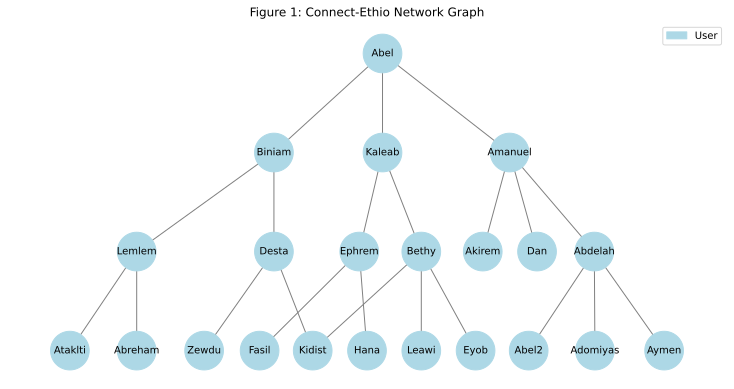

In [99]:
display_network(sample_network, title="Figure 1: Connect-Ethio Network Graph")

## Task B: Breadth-First Search (BFS)

### BFS Algorithm & Implementation

In [101]:
def bfs(self, source, target):
    """
    Breadth-First Search from source to target.
    Returns the shortest path as a list of users, or None if unreachable.
    """
    if source not in self.graph.keys():
        print(f'Error: User "{source}" not found in the network.')
        return None
    if target not in self.graph.keys():
        print(f'Error: User "{target}" not found in the network.')
        return None

    visited = set([source])
    queue   = deque([[source]])  # each element is a path list
    i = 1
    while queue:
        path = queue.popleft()   # FIFO — always the shortest front
        node = path[-1]

        if node == target:
            return path          # shortest path found

        for neighbour in self.graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(path + [neighbour])
        i += 1

    return None  # no path exists

# add bfs method to the network object
ConnectEthio.bfs = bfs

# === Run BFS ===
bfs_result = sample_network.bfs('Abel', 'Zewdu')
if bfs_result:
    print(f'BFS Shortest Path : {" -> ".join(bfs_result)}')
    print(f'Total Distance    : {len(bfs_result) - 1} edges')
else:
    print('Path Not Found.')

BFS Shortest Path : Abel -> Biniam -> Desta -> Zewdu
Total Distance    : 3 edges


### BFS Path Visualisation

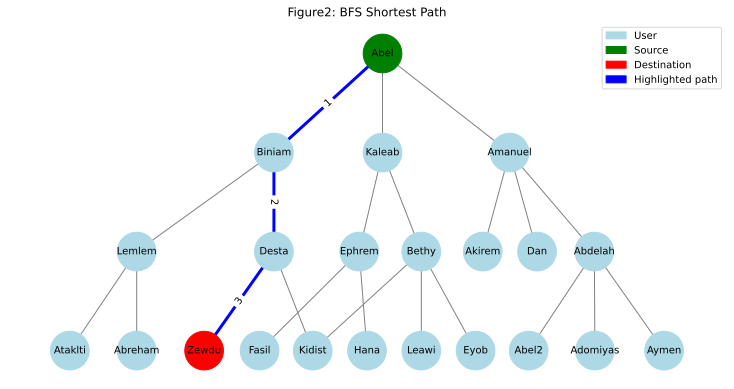

In [102]:
# convert bfs result into edges
bfs_edges = list(zip(bfs_result, bfs_result[1:]))
display_network(sample_network, source="Abel", target="Zewdu", highlight_edges=bfs_edges, title="Figure2: BFS Shortest Path")

## Task C: Depth-First Search (DFS)

### DFS Algorithm & Implementation

In [103]:
def dfs(self, source, target):
    """
    Depth-First Search from source to target.
    Returns any valid path as a list of users, or None if unreachable.
    """
    if source not in self.graph.keys():
        print(f'Error: User "{source}" not found in the network.')
        return None
    if target not in self.graph.keys():
        print(f'Error: User "{target}" not found in the network.')
        return None
    
    visited = set()
    stack   = [(source, [source])]  # (current_node, path_so_far)
    
    while stack:
        node, path = stack.pop()    # LIFO — go deep first
    
        if node == target:
            return path             # valid path found (not necessarily shortest)
    
        if node not in visited:
            visited.add(node)
            for neighbour in reversed(self.graph[node]):
                if neighbour not in visited:
                    stack.append((neighbour, path + [neighbour]))
    
    return None  # no path exists

# add bfs method to the network object
ConnectEthio.dfs = dfs

# === Run DFS ===
dfs_result = sample_network.dfs('Abel', 'Zewdu')
if dfs_result:
    print(f'DFS Path       : {" -> ".join(dfs_result)}')
    print(f'Total Distance : {len(dfs_result) - 1} edges')
else:
    print('Path Not Found.')

DFS Path       : Abel -> Biniam -> Desta -> Zewdu
Total Distance : 3 edges


### DFS Path Visualisation

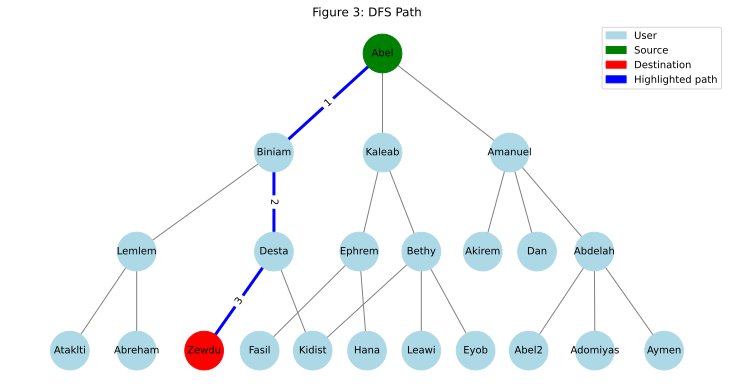

In [104]:
# convert dfs result into edges
dfs_edges = list(zip(dfs_result, dfs_result[1:]))
display_network(sample_network, source="Abel", target="Zewdu", highlight_edges=dfs_edges, title="Figure 3: DFS Path")

## Space Complexity at Scale

In [ ]:
import tracemalloc

def graph_to_connect_ethio(G):
    """
    Convert networkx graph into ConnectEthio Graph
    """
    network = ConnectEthio()

    for u, v in G.edges():
        network.add_connection(u, v)

    return network


def measure_memory(func, *args):
    """
    Measures peak memory used by func(*args)
    """
    tracemalloc.start()

    func(*args)

    current, peak = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    # convert to KB
    return peak / 1024


n_users = [1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]
results = {
    "bfs": {},
    "dfs": {}
}
for n in n_users:
    # generate a complete 3-ary tree with n number of nodes
    G = nx.full_rary_tree(r=3, n=n)

    # convert the generated graph into our network implementation
    network = graph_to_connect_ethio(G)

    source_node = 0
    target_node = max(network.graph.keys())

    # Measure BFS memory
    bfs_memory = measure_memory(network.bfs, source_node, target_node)

    # Measure DFS memory
    dfs_memory = measure_memory(network.dfs, source_node, target_node)

    results["bfs"][n] = bfs_memory
    results["dfs"][n] = dfs_memory

In [106]:
results

{'bfs': {1000: 106.6875,
  5000: 1060.1044921875,
  10000: 1397.0859375,
  50000: 6900.546875,
  100000: 14094.4609375,
  500000: 70375.703125,
  1000000: 143887.5625},
 'dfs': {1000: 41.4140625,
  5000: 160.859375,
  10000: 11.0,
  50000: 2561.96875,
  100000: 642.4453125,
  500000: 24578.5625,
  1000000: 12290.453125}}

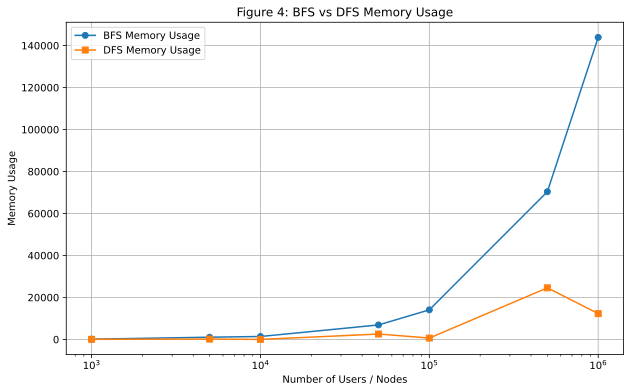

In [109]:
# Extract x and y values
x = n_users
bfs_y = [results["bfs"][n] for n in x]
dfs_y = [results["dfs"][n] for n in x]

# Create the plot
plt.figure(figsize=(10, 6))

plt.plot(x, bfs_y, marker='o', label='BFS Memory Usage')
plt.plot(x, dfs_y, marker='s', label='DFS Memory Usage')

# Labels and title
plt.xlabel("Number of Users / Nodes")
plt.ylabel("Memory Usage")
plt.title("Figure 4: BFS vs DFS Memory Usage")

plt.xscale("log")

# Grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()

## Edge Case: Deleted Account (Isolated Node)

In [110]:
def delete_user(self, user):
    """
    Remove a user and all their connections from the network.
    """
    if user not in self.graph:
        print(f'User "{user}" not found in the network.')
        return

    # Remove this user from all of their neighbors
    for neighbour in self.graph[user]:
        if user in self.graph[neighbour]:
            self.graph[neighbour].remove(user)

    # Remove the user itself
    del self.graph[user]


ConnectEthio.delete_user = delete_user

User "Desta" not found in the network.


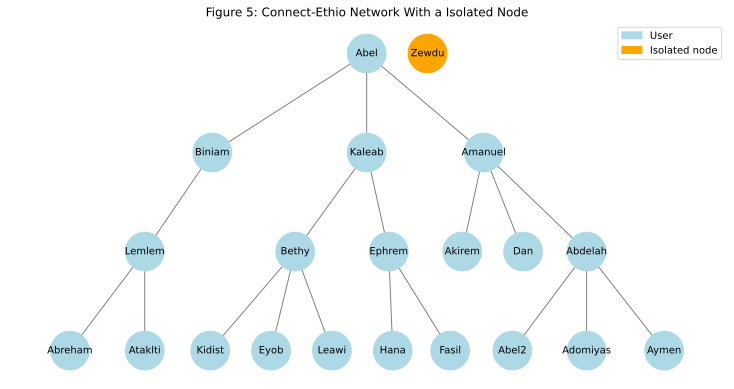

In [114]:
sample_network.delete_user("Desta")
display_network(sample_network, title="Figure 5: Connect-Ethio Network With a Isolated Node")

In [113]:
# === Run BFS ===
bfs_result = sample_network.bfs('Abel', 'Zewdu')
if bfs_result:
    print(f'BFS Shortest Path : {" -> ".join(bfs_result)}')
    print(f'Total Distance    : {len(bfs_result) - 1} edges')
else:
    print('Path Not Found.')

Path Not Found.


In [112]:
dfs_result = sample_network.dfs('Abel', 'Zewdu')
if dfs_result:
    print(f'DFS Path       : {" -> ".join(dfs_result)}')
    print(f'Total Distance : {len(dfs_result) - 1} edges')
else:
    print('Path Not Found.')

Path Not Found.
